In [1]:
import pandas as pd
from thetadata import ThetaClient
import os
import glob
from datetime import date, time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
files = glob.glob("../data/raw/greeks/SPY/*.parquet")
raw_df = pd.concat([pd.read_parquet(f) for f in sorted(files)], ignore_index=True)

In [3]:
# A very basic filter
df = raw_df[
    (raw_df['implied_vol'] > 0)
    & (raw_df['iv_error'] < 1.0)
    & (raw_df['delta'].abs().between(0.01, 0.99))
    & (raw_df['bid'] > 0)
].copy()
# after cleaning data, length 93366 -> 16100

# verification & visualization

In [100]:
# Check the timezone info on the timestamp column
ts = df['timestamp'].iloc[0]
print(type(ts))     # pandas.Timestamp
print(ts)           # time offset: 2026-05-06 10:30:00-04:00
                    # local time 2026-05-06 10:30:00. -04:00 means 4 hours behind UTC
                    # UTC: 10:30 + 4:00 = 14:30 UTC
print(ts.tzinfo)    # America/New_York
# Sanity check: market open at 9:30 and close at 16:00
print(df['timestamp'].dt.hour.min())  # 9
print(df['timestamp'].max())

<class 'pandas.Timestamp'>
2026-05-06 10:30:00-04:00
America/New_York
9
2026-05-19 16:00:00-04:00


In [101]:
# SPY data on 2026-01-02
# arbitrary winter day to check daylight saving effect in timezone
client = ThetaClient(dataframe_type='pandas')
exp = date(2026, 1, 2)
winterdf = client.option_history_greeks_first_order(
    symbol="SPY",
    expiration=exp,
    start_date=exp,
    end_date=exp,
    interval='15m',
)

In [102]:
# Check the timezone info on the timestamp column
ts = winterdf['timestamp'].iloc[0]
print(ts)           # time offset: 2026-01-02 09:30:00-05:00
                    # no daylight saving, 5 hours behind UTC
print(ts.tzinfo)    # America/New_York
# market still open at 9:30 and close at 16:00
print(winterdf['timestamp'].min())
print(winterdf['timestamp'].max())

2026-01-02 09:30:00-05:00
America/New_York
2026-01-02 09:30:00-05:00
2026-01-02 16:00:00-05:00


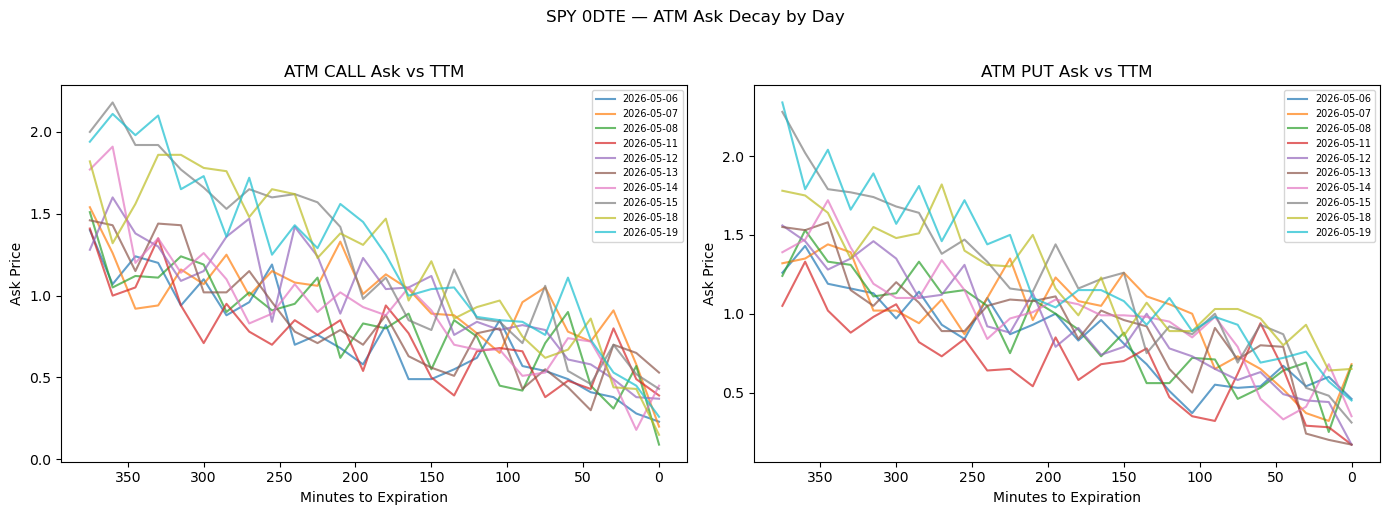

In [103]:
# ATM Call / Put ask price vs time to maturity
# For each (expiration, timestamp, right), pick the strike closest to underlying
df['strike_dist'] = (df['strike'] - df['underlying_price']).abs()
atm_df = df.loc[
    df.groupby(['expiration', 'timestamp', 'right'])['strike_dist'].idxmin()
].copy()

# Time to maturity in minutes (0DTE expires at 4pm ET)
close_dt = atm_df['timestamp'].apply(
    lambda t: t.replace(hour=16, minute=0, second=0, microsecond=0)
)
atm_df['ttm_min'] = (close_dt - atm_df['timestamp']).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, right in zip(axes, ['CALL', 'PUT']):
    subset = atm_df[atm_df['right'] == right]
    for exp, grp in subset.groupby('expiration'):
        ax.plot(grp['ttm_min'], grp['ask'], label=str(exp), alpha=0.7, linewidth=1.5)
    ax.invert_xaxis()  # left = open, right = close
    ax.set_xlabel('Minutes to Expiration')
    ax.set_ylabel('Ask Price')
    ax.set_title(f'ATM {right} Ask vs TTM')
    ax.legend(fontsize=7)

plt.suptitle('SPY 0DTE — ATM Ask Decay by Day', y=1.02)
plt.tight_layout()
plt.show()

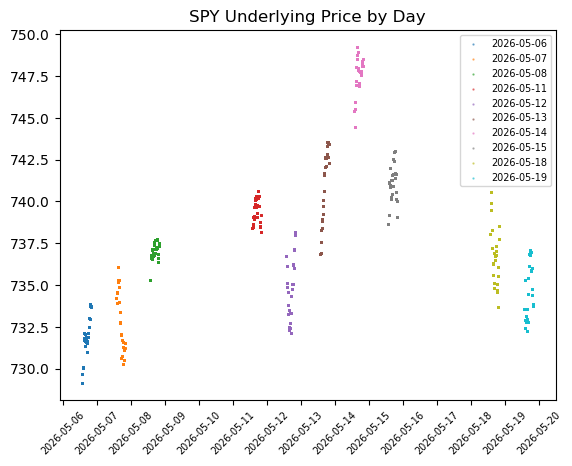

In [104]:
# underlying price
fig, ax = plt.subplots()
for exp, grp in df.groupby('expiration'):
    plt.scatter(grp['timestamp'], grp['underlying_price'], s=0.4, alpha=0.6, label=str(exp))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, fontsize=7)
plt.legend(fontsize=7)
plt.title('SPY Underlying Price by Day')
plt.show()

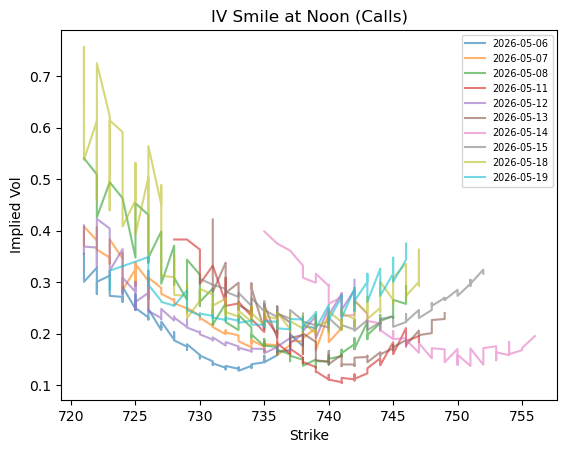

In [105]:
# IV smile
noon = df[(df['timestamp'].dt.hour == 12) & (df['strike'] > 720)]
for exp, grp in noon.groupby('expiration'):
    grp_sorted = grp[grp['right'] == 'CALL'].sort_values('strike')
    plt.plot(grp_sorted['strike'], grp_sorted['implied_vol'], alpha=0.6, label=str(exp))
plt.title('IV Smile at Noon (Calls)')
plt.legend(fontsize=7)
plt.xlabel('Strike')
plt.ylabel('Implied Vol')
plt.show()

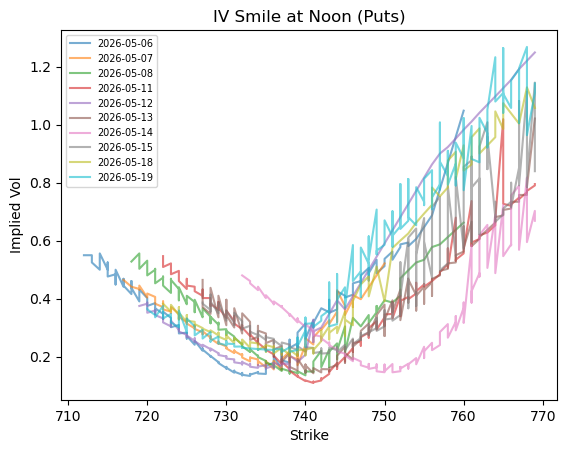

In [106]:
# IV smile
noon = df[(df['timestamp'].dt.hour == 12) & (df['strike'] < 770)]
for exp, grp in noon.groupby('expiration'):
    grp_sorted = grp[grp['right'] == 'PUT'].sort_values('strike')
    plt.plot(grp_sorted['strike'], grp_sorted['implied_vol'], alpha=0.6, label=str(exp))
plt.title('IV Smile at Noon (Puts)')
plt.legend(fontsize=7)
plt.xlabel('Strike')
plt.ylabel('Implied Vol')
plt.show()

# Data construction

In [4]:
# filter out 16:00 and 9:30 data
df = df[df['timestamp'].dt.hour != 16]
df = df[(df['timestamp'].dt.hour != 9) | (df['timestamp'].dt.minute != 30)]
df.shape

(15652, 17)

In [5]:
# add closing price of the day as a new column spy_close
closing = pd.read_csv("../data/processed/spy_closing_prices.csv")
closing["date"] = pd.to_datetime(closing["date"])

df["expiration"] = pd.to_datetime(df["expiration"])

df = df.merge(
    closing.rename(columns={"date": "expiration", "closing_price": "spy_close"}),
    on="expiration",
    how="left",
)

# Verify if all data sharing the same expiration also shares the same spy_close
assert df.groupby("expiration")["spy_close"].nunique().eq(1).all(), \
    "Some expirations have multiple closing prices"

# add opening price of the day as a new column spy_open
opening = pd.read_csv("../data/processed/spy_opening_prices.csv")
opening["date"] = pd.to_datetime(opening["date"])

df["expiration"] = pd.to_datetime(df["expiration"])

df = df.merge(
    opening.rename(columns={"date": "expiration", "opening_price": "spy_open"}),
    on="expiration",
    how="left",
)
assert df.groupby("expiration")["spy_open"].nunique().eq(1).all(), \
    "Some expirations have multiple opening prices"


In [8]:
df["log_return_from_open"] = np.log(df["underlying_price"] / df["spy_open"])

In [9]:
df["log_return"] = np.log(df["spy_close"] / df["underlying_price"])

In [10]:
# 0dte precision concern
# find minimum precision needed for log return
for k in range(2, 12):
    reconstructed = np.exp(df["log_return"].round(k)) * df["underlying_price"]
    all_match = (reconstructed.round(2) == df["spy_close"]).all()
    print(f"decimal places={k}: all match = {all_match}")

decimal places=2: all match = False
decimal places=3: all match = False
decimal places=4: all match = False
decimal places=5: all match = True
decimal places=6: all match = True
decimal places=7: all match = True
decimal places=8: all match = True
decimal places=9: all match = True
decimal places=10: all match = True
decimal places=11: all match = True


In [11]:
# log-return currently in .6f
# check if closing price reconstruction all match
df["spy_close_reconstructed"] = (np.exp(df["log_return"]) * df["underlying_price"]).round(2)
diff = (df["spy_close_reconstructed"] - df["spy_close"]).abs()
print(f"Max difference:  {diff.max()}")
print(f"Mean difference: {diff.mean():.6f}")
print(f"All match: {(df['spy_close_reconstructed'] == df['spy_close']).all()}")

Max difference:  0.0
Mean difference: 0.000000
All match: True
